In [ ]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/HW1"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

* The objective of this experiment is to determine if the time IPAs are aged affects their IBU, based on these 3 time frames.


**Question 2.** Specify the outcome variable

* Outcome variable: IBU (continuous numeric variable)

**Question 3.** Specify the independent variable. What are some possible lurking variables?

* Independent variable: Weeks (nominal categorical variable)
* Lurking variable: There could be a lurking variable if the beers were stored in different bottles. Ideally all beers in each aging tank would be stored in the sane type of bottle at the same time.


**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

* A completely randomized design may be appropriate for this experiment because there are three mutually exclusive time ranges we'd like to compare. There is no other knowable sources of variation from lurking variables. We are randomly brewing and aging the beers without many other sources of variation that we would need to control.

**Question 5.** State the null and alternative hypotheses for this experiment.

$$ \begin{align}
H_0&: \mu_{\text{3 Weeks}} = \mu_{\text{4 Weeks}} = \mu_{\text{5 Weeks}} \\
H_1&: \text{At least one pair of means differ substantially}
\end{align}
$$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weeks   30 non-null     object 
 1   IBU     30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
None
           mean       std
Weeks                    
3 Weeks  49.216  8.300656
4 Weeks  62.751  8.250384
5 Weeks  69.725  5.631258


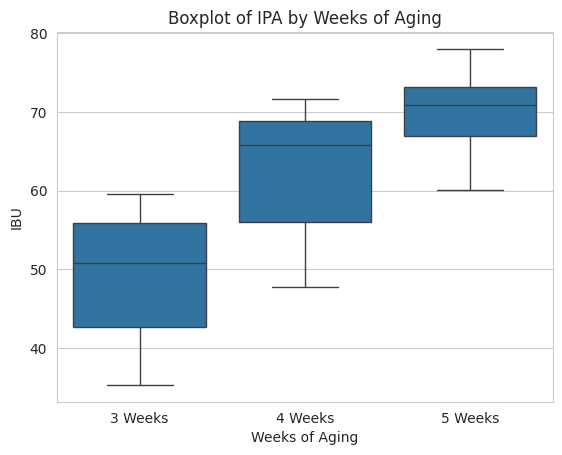

In [10]:
## Import Necessary Python Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

##Import the IPA Data ##

ipa_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW1/IPA.xlsx")

## Data Integrity Check with .info ##

print(ipa_data.info())

## Calculate Mean and Standard Deviation
## of IBUs by Weeks ##

ipa_stats = ipa_data.groupby('Weeks')['IBU'].agg(['mean','std'])

print(ipa_stats) # Corrected variable name from ipa_stats to ipa

## Generate Boxplot for Visual Comparison ##

## Set style (default is "darkgrid") ##

sns.set_style("whitegrid")
## Create boxplot ##

sns.boxplot(x="Weeks",y="IBU",data=ipa_data)

## Add Title and Labels ##

plt.title("Boxplot of IPA by Weeks of Aging", loc='center')
plt.xlabel("Weeks of Aging")
plt.ylabel("IBU")
plt.show()

* The results of these statitics support the altrnative hypothesis more than the null hypothesis.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



In [12]:
## Fit One-Way ANOVA Model ##

ipa_mod = ols("IBU~Weeks",data=ipa_data).fit()

## Print ANOVA Table Adding Significance Column ##

tab = sm.stats.anova_lm(ipa_mod,typ=1)

tab["Significant"] = np.where(tab["PR(>F)"]<0.05,"Yes","No")

print(tab)

            df      sum_sq      mean_sq          F    PR(>F) Significant
Weeks      2.0  2174.83994  1087.419970  19.339842  0.000006         Yes
Residual  27.0  1518.12718    56.226933        NaN       NaN          No


**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

*



**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

* The F statistics is 19.3398 and the p-value is 0.000006. Due to the p-value being under 0.05, the results support the alternative hypothesis.


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.




 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   13.535 0.0011  5.2205 21.8495   True
3 Weeks 5 Weeks   20.509    0.0 12.1945 28.8235   True
4 Weeks 5 Weeks    6.974 0.1131 -1.3405 15.2885  False
------------------------------------------------------


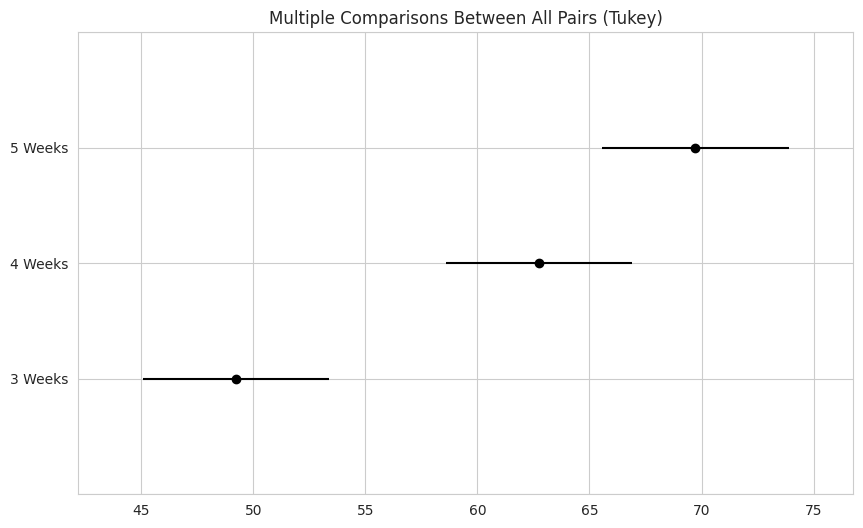

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##

tukey_result = pairwise_tukeyhsd(endog=ipa_data['IBU'], groups=ipa_data['Weeks'],
                                 alpha=0.05)

## Print Tukey Visualization ##

tukey_result.plot_simultaneous()

## Print Tukey Table ##

print(tukey_result)

* The mean IBU of 3 weeks is significantly different from the mean IBU of 4 and 5 weeks. There is not a significant difference between the mean IBU of 4 weeks and 5 weeks.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.

*